##  Forecasting Indian Oil Corporation Stock Prices Using ARIMA and SARIMA: A Time Series Approach

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use("ggplot")
np.random.seed(42)


## Data Collection

In [2]:
ticker = "IOC.NS"

data = yf.download(
    ticker,
    start="2010-01-01",
    end="2026-01-01",
    auto_adjust=True
)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data.reset_index()

stock_data = data[["Date", "Close"]].copy()

stock_data["Date"] = pd.to_datetime(stock_data["Date"])
stock_data["Close"] = pd.to_numeric(
    stock_data["Close"],
    errors="coerce"
)

stock_data = (
    stock_data
    .dropna()
    .sort_values("Date")
    .drop_duplicates(subset="Date")
)

stock_data.to_csv(
    "IOC_NS_stock_data.csv",
    index=False
)

print("CSV saved successfully!")
print(stock_data.head())
print(stock_data.shape)

[*********************100%***********************]  1 of 1 completed

CSV saved successfully!
Price       Date      Close
0     2010-01-04  23.017374
1     2010-01-05  23.105156
2     2010-01-06  23.072237
3     2010-01-07  22.710133
4     2010-01-08  23.097841
(3949, 2)


This downloads historical IOC.NS stock data from Yahoo Finance for the selected period and keeps the Date and Closing Price.
The data is cleaned by handling dates, missing values, duplicates, and sorting it chronologically.
Finally, the cleaned data is saved as a CSV file, and its first few rows and dimensions are displayed.

## Exploratory Data Analysis and Preprocessing

In [3]:
IOC = pd.read_csv(
    "IOC_NS_stock_data.csv",
    parse_dates=["Date"]
)

IOC = IOC.set_index("Date")

IOC = IOC.sort_index()
IOC.index = pd.to_datetime(IOC.index)
IOC = IOC[~IOC.index.duplicated(keep="first")]
IOC = IOC.sort_index()

In [4]:
print("Start:", IOC.index.min())
print("End:", IOC.index.max())
print("Observations:", len(IOC))
print("Duplicate dates:", IOC.index.duplicated().sum())

Start: 2010-01-04 00:00:00
End: 2025-12-31 00:00:00
Observations: 3949
Duplicate dates: 0


The data is loaded, organized by date, and checked for duplicate records.
Basic information such as the date range, number of observations, and duplicate dates is also verified.

In [5]:
print("\nFinal dataset:")
print(IOC.head())

print("\nShape:")
print(IOC.shape)

print("\nDataset Information:")
IOC.info()

print("\nMissing values:")
print(IOC.isnull().sum())

print("\nDuplicate rows:")
print(IOC.duplicated().sum())

print("\nDuplicate dates:")
print(IOC.index.duplicated().sum())

print("\nIndex type:")
print(IOC.index.dtype)


Final dataset:
                Close
Date                 
2010-01-04  23.017374
2010-01-05  23.105156
2010-01-06  23.072237
2010-01-07  22.710133
2010-01-08  23.097841

Shape:
(3949, 1)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3949 entries, 2010-01-04 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3949 non-null   float64
dtypes: float64(1)
memory usage: 61.7 KB

Missing values:
Close    0
dtype: int64

Duplicate rows:
334

Duplicate dates:
0

Index type:
datetime64[ns]


In [6]:
print("\nSummary Statistics:")
print(IOC["Close"].describe())


Summary Statistics:
count    3949.000000
mean       56.161435
std        37.569372
min        15.313770
25%        27.063854
50%        49.655048
75%        67.360352
max       171.679657
Name: Close, dtype: float64


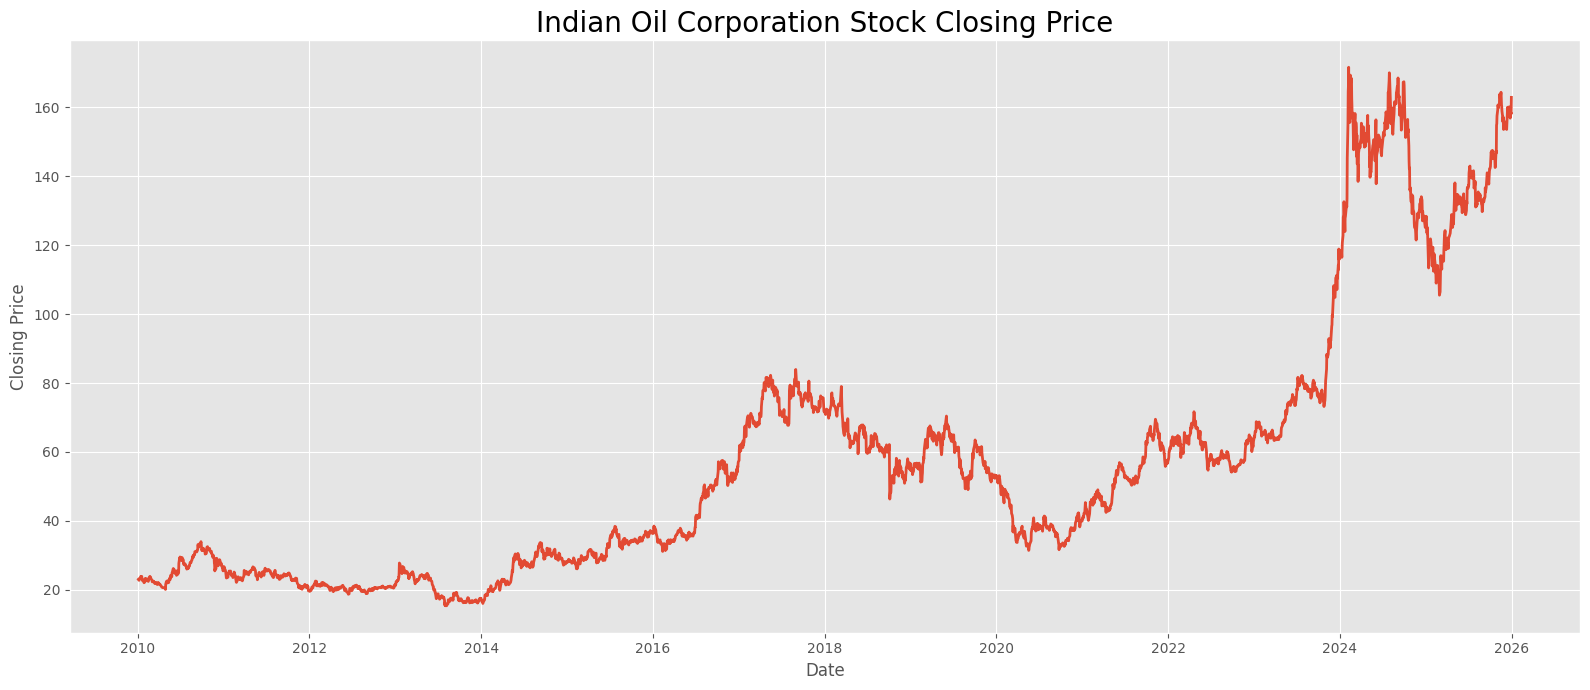

In [7]:
plt.figure(figsize=(16, 7))

plt.plot(
    IOC.index,
    IOC["Close"],
    linewidth=2
)

plt.title("Indian Oil Corporation Stock Closing Price", fontsize=20)
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.tight_layout()
plt.show()

This plot shows the historical closing price of Indian Oil Corporation over time.
It helps visualize the overall trend, major price fluctuations, and periods of significant increases or declines.

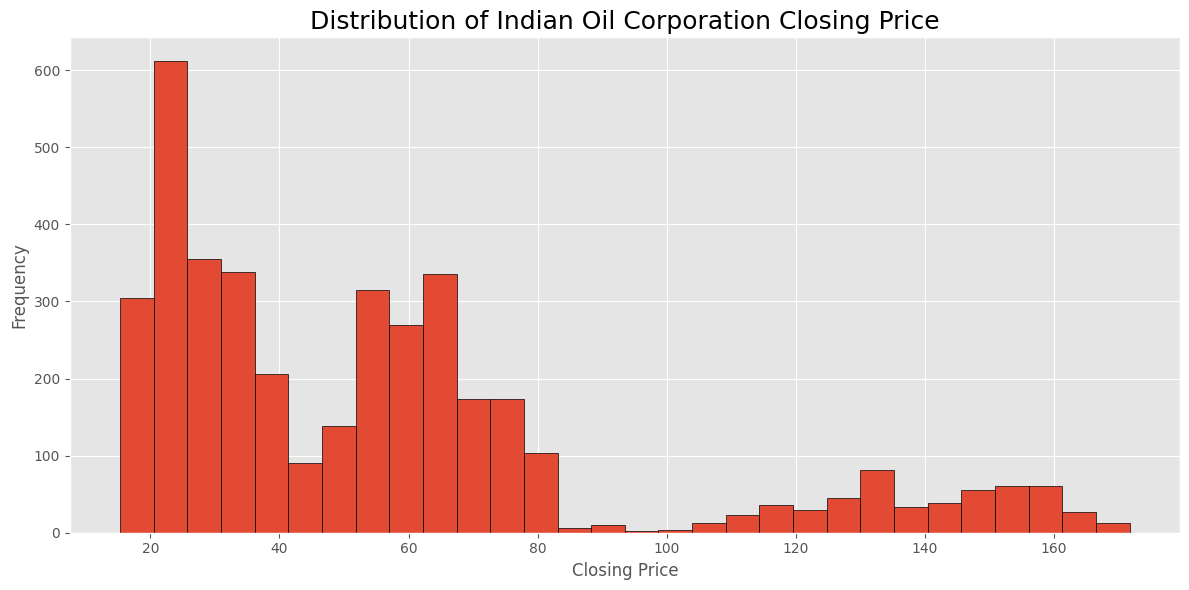

In [8]:
plt.figure(figsize=(12, 6))

plt.hist(
    IOC["Close"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Indian Oil Corporation Closing Price", fontsize=18)
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

This histogram shows the distribution of IOC closing prices and how frequently different price ranges occur.
It helps understand the spread, concentration, and skewness of the stock price data.


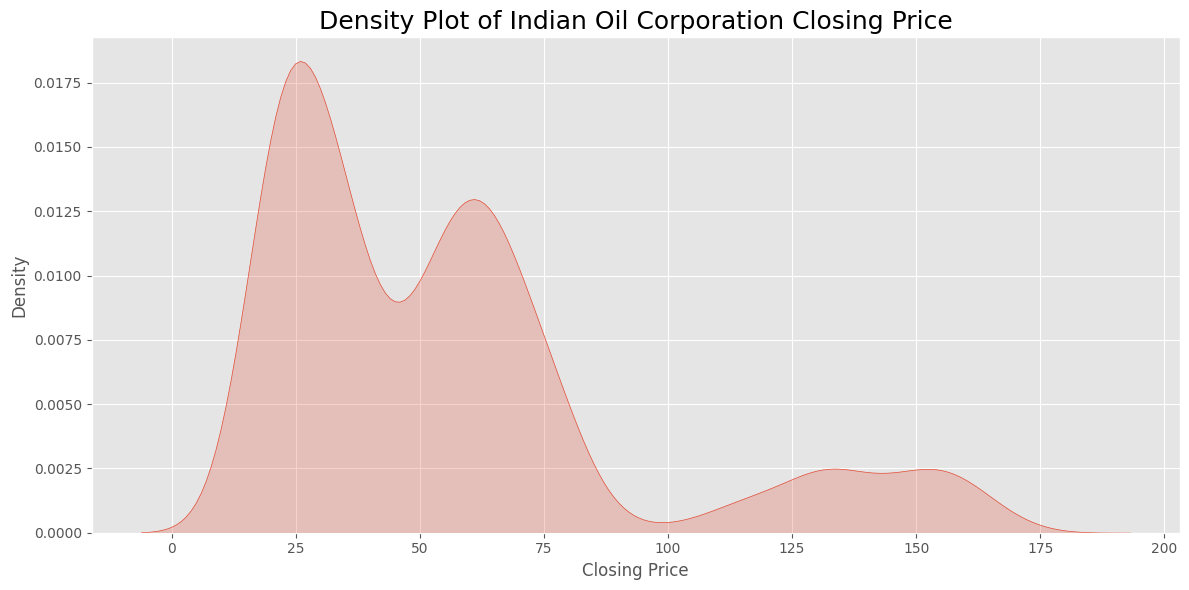

In [9]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=IOC,
    x="Close",
    fill=True
)

plt.title("Density Plot of Indian Oil Corporation Closing Price", fontsize=18)
plt.xlabel("Closing Price")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

This density plot provides a smooth view of the distribution of IOC closing prices.
It helps identify the concentration, spread, and multiple peaks in the stock price distribution.

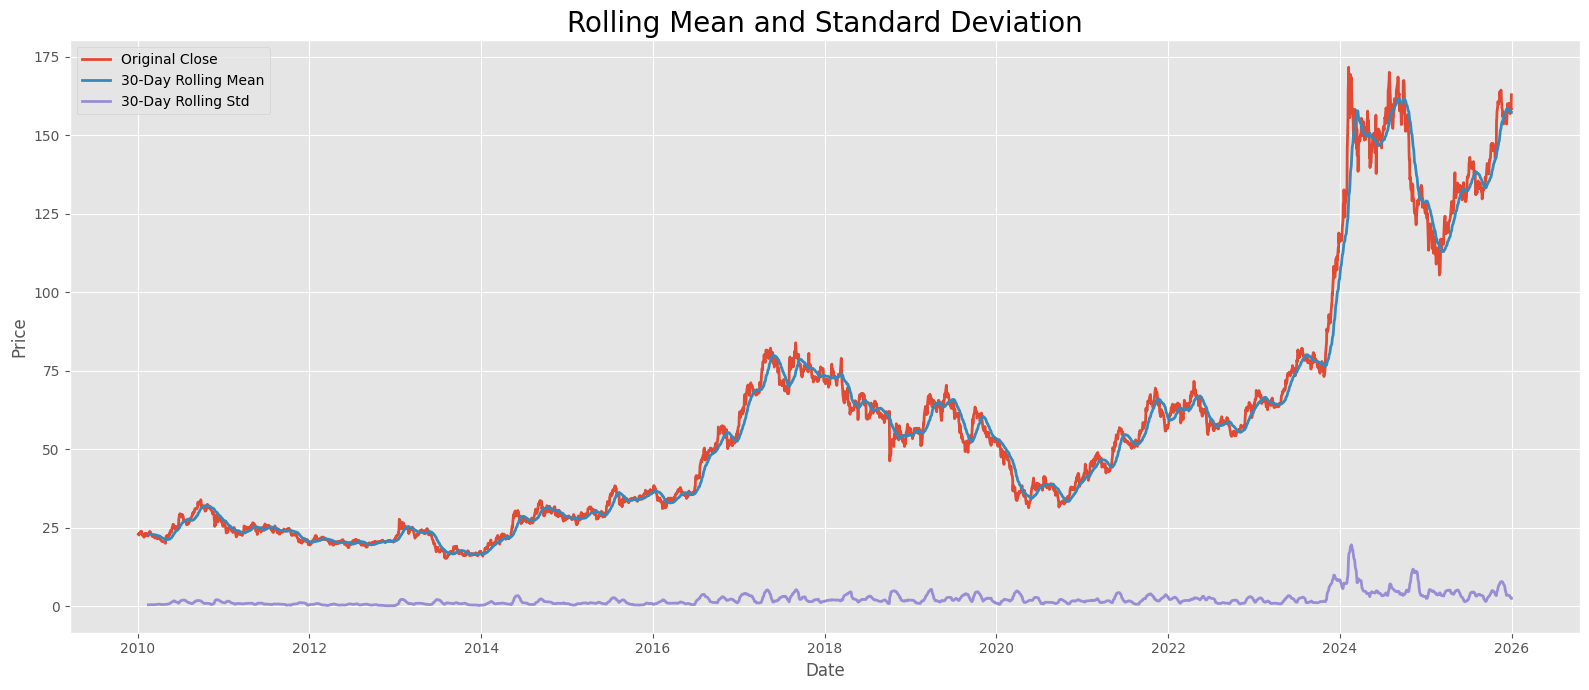

In [10]:
rolling_window = 30

rolling_mean = IOC["Close"].rolling(
    window=rolling_window
).mean()

rolling_std = IOC["Close"].rolling(
    window=rolling_window
).std()

plt.figure(figsize=(16, 7))

plt.plot(
    IOC["Close"],
    label="Original Close",
    linewidth=2
)

plt.plot(
    rolling_mean,
    label=f"{rolling_window}-Day Rolling Mean",
    linewidth=2
)

plt.plot(
    rolling_std,
    label=f"{rolling_window}-Day Rolling Std",
    linewidth=2
)

plt.title("Rolling Mean and Standard Deviation", fontsize=20)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.tight_layout()
plt.show()


A 30-day rolling mean and standard deviation are calculated to examine the stock price trend and its short-term variability.
The rolling mean smooths the price series, while the rolling standard deviation shows changes in volatility over time.
This helps identify periods of relatively stable and highly volatile price movements.

In [11]:
def adf_test(series, name="Series"):
    series = series.dropna()

    result = adfuller(
        series,
        autolag="AIC"
    )

    print(f"\nADF Test: {name}")
    print("-" * 50)

    print(f"Test Statistic    : {result[0]:.6f}")
    print(f"p-value           : {result[1]:.6f}")
    print(f"Lags Used         : {result[2]}")
    print(f"Observations Used : {result[3]}")

    print("\nCritical Values:")

    for key, value in result[4].items():
        print(f"  {key}: {value:.6f}")

    if result[1] <= 0.05:
        print("\nConclusion:")
        print("Reject H0 -> The series is likely stationary.")
    else:
        print("\nConclusion:")
        print("Fail to reject H0 -> The series is likely non-stationary.")

    return result

In [12]:
adf_original = adf_test(
    IOC["Close"],
    "Original Indian Oil Corporation Closing Price"
)



ADF Test: Original Indian Oil Corporation Closing Price
--------------------------------------------------
Test Statistic    : 0.578559
p-value           : 0.987075
Lags Used         : 29
Observations Used : 3919

Critical Values:
  1%: -3.432020
  5%: -2.862278
  10%: -2.567163

Conclusion:
Fail to reject H0 -> The series is likely non-stationary.


The Augmented Dickey-Fuller (ADF) test is applied to check whether the original closing-price series is stationary.
The high p-value (0.9871) indicates insufficient evidence to reject the null hypothesis, suggesting that the series is non-stationary.

In [13]:
close_diff = IOC["Close"].diff().dropna()

print("\nFirst differenced series:")
print(close_diff.head())


First differenced series:
Date
2010-01-05    0.087782
2010-01-06   -0.032919
2010-01-07   -0.362104
2010-01-08    0.387709
2010-01-11    0.226774
Name: Close, dtype: float64


The first difference of the closing-price series is calculated to remove the trend and help make the series stationary.
The resulting differenced values are displayed to verify the transformation before further time-series analysis.

In [14]:
IOC["Log_Return"] = np.log(
    IOC["Close"] / IOC["Close"].shift(1)
)

log_returns = IOC["Log_Return"].dropna()

In [15]:
adf_diff = adf_test(
    close_diff,
    "First-Differenced Indian Oil Corporation Closing Price"
)


ADF Test: First-Differenced Indian Oil Corporation Closing Price
--------------------------------------------------
Test Statistic    : -11.746743
p-value           : 0.000000
Lags Used         : 28
Observations Used : 3919

Critical Values:
  1%: -3.432020
  5%: -2.862278
  10%: -2.567163

Conclusion:
Reject H0 -> The series is likely stationary.


The first-differenced series is tested using the ADF test and is found to be stationary, with a p-value of 0.0000.
Log returns are also calculated to capture the relative day-to-day changes in the stock price.

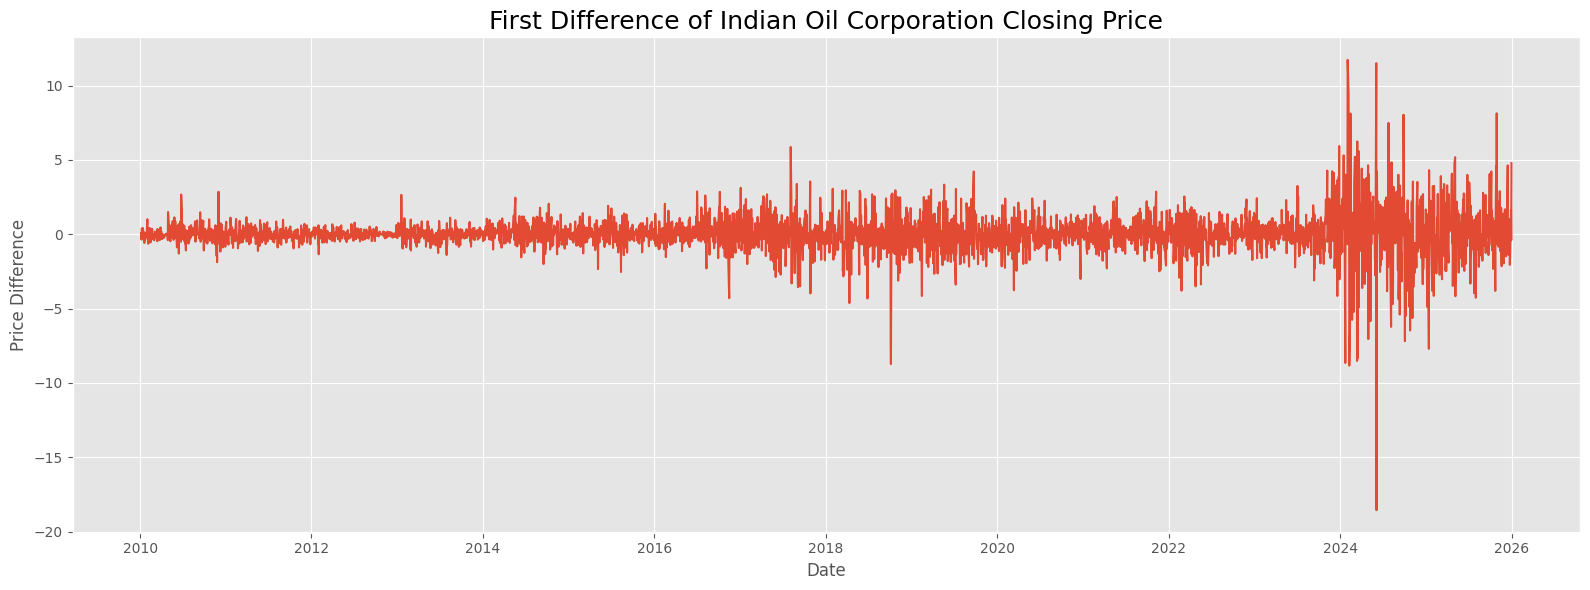

In [16]:
plt.figure(figsize=(16, 6))

plt.plot(
    close_diff,
    linewidth=1.5
)

plt.title(
    "First Difference of Indian Oil Corporation Closing Price",
    fontsize=18
)

plt.xlabel("Date")
plt.ylabel("Price Difference")

plt.tight_layout()
plt.show()


The plot shows the first-differenced closing prices fluctuating around zero, indicating that the trend has been removed.
It also highlights periods of higher volatility, particularly in the later part of the series.

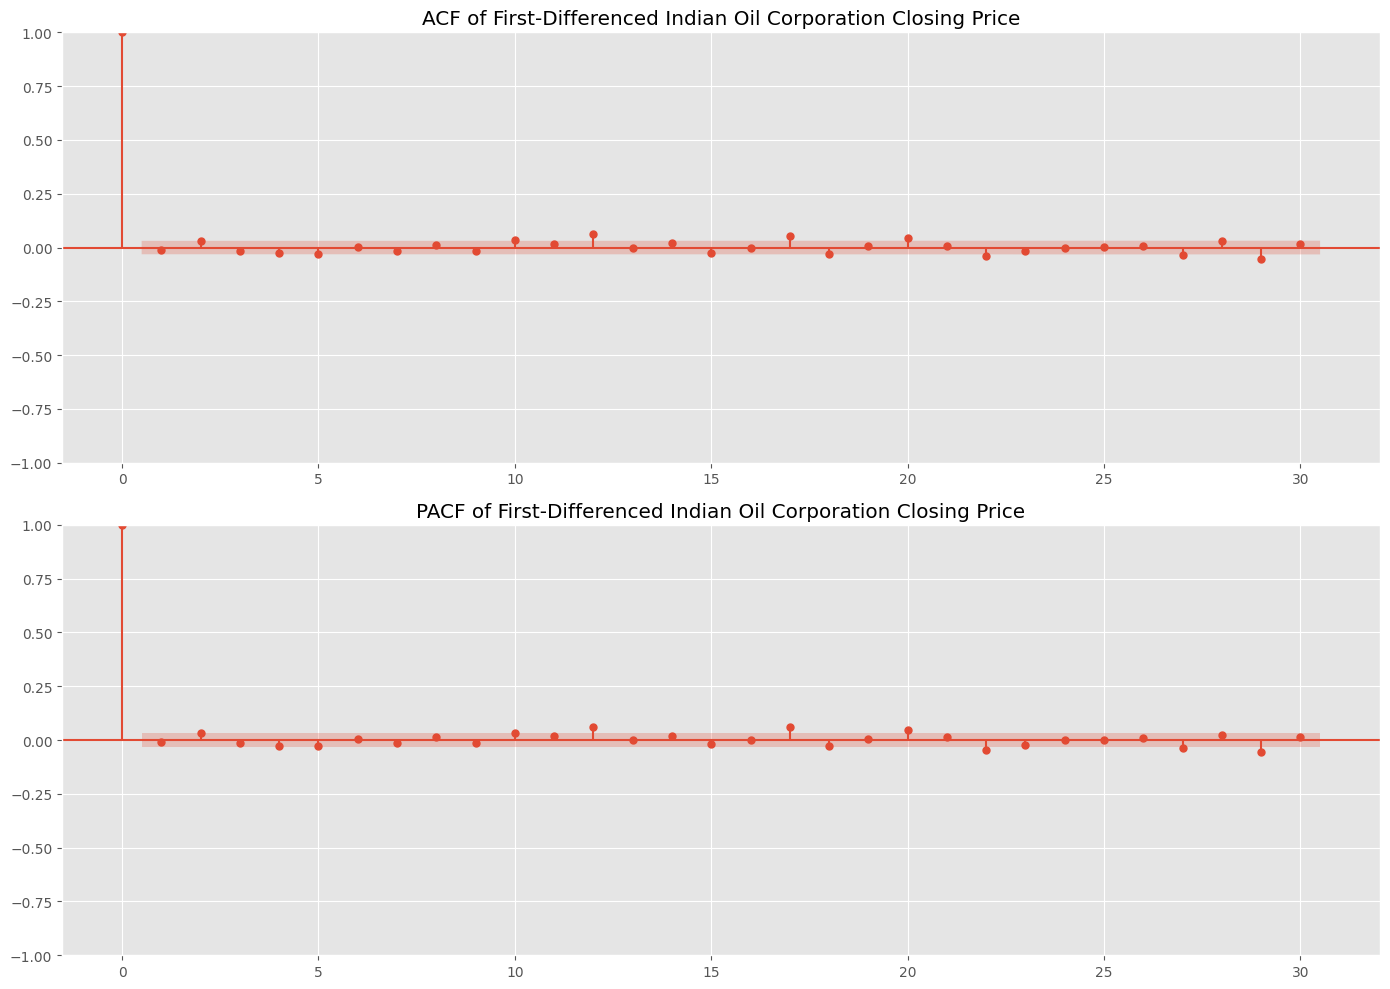

In [17]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)

plot_acf(
    close_diff,
    ax=axes[0],
    lags=30
)

axes[0].set_title(
    "ACF of First-Differenced Indian Oil Corporation Closing Price"
)

plot_pacf(
    close_diff,
    ax=axes[1],
    lags=30,
    method="ywm"
)

axes[1].set_title(
    "PACF of First-Differenced Indian Oil Corporation Closing Price"
)

plt.tight_layout()
plt.show()

The ACF and PACF plots examine the autocorrelation structure of the first-differenced series at different lags.
They help identify possible AR and MA terms and guide the selection of suitable ARIMA model parameters.

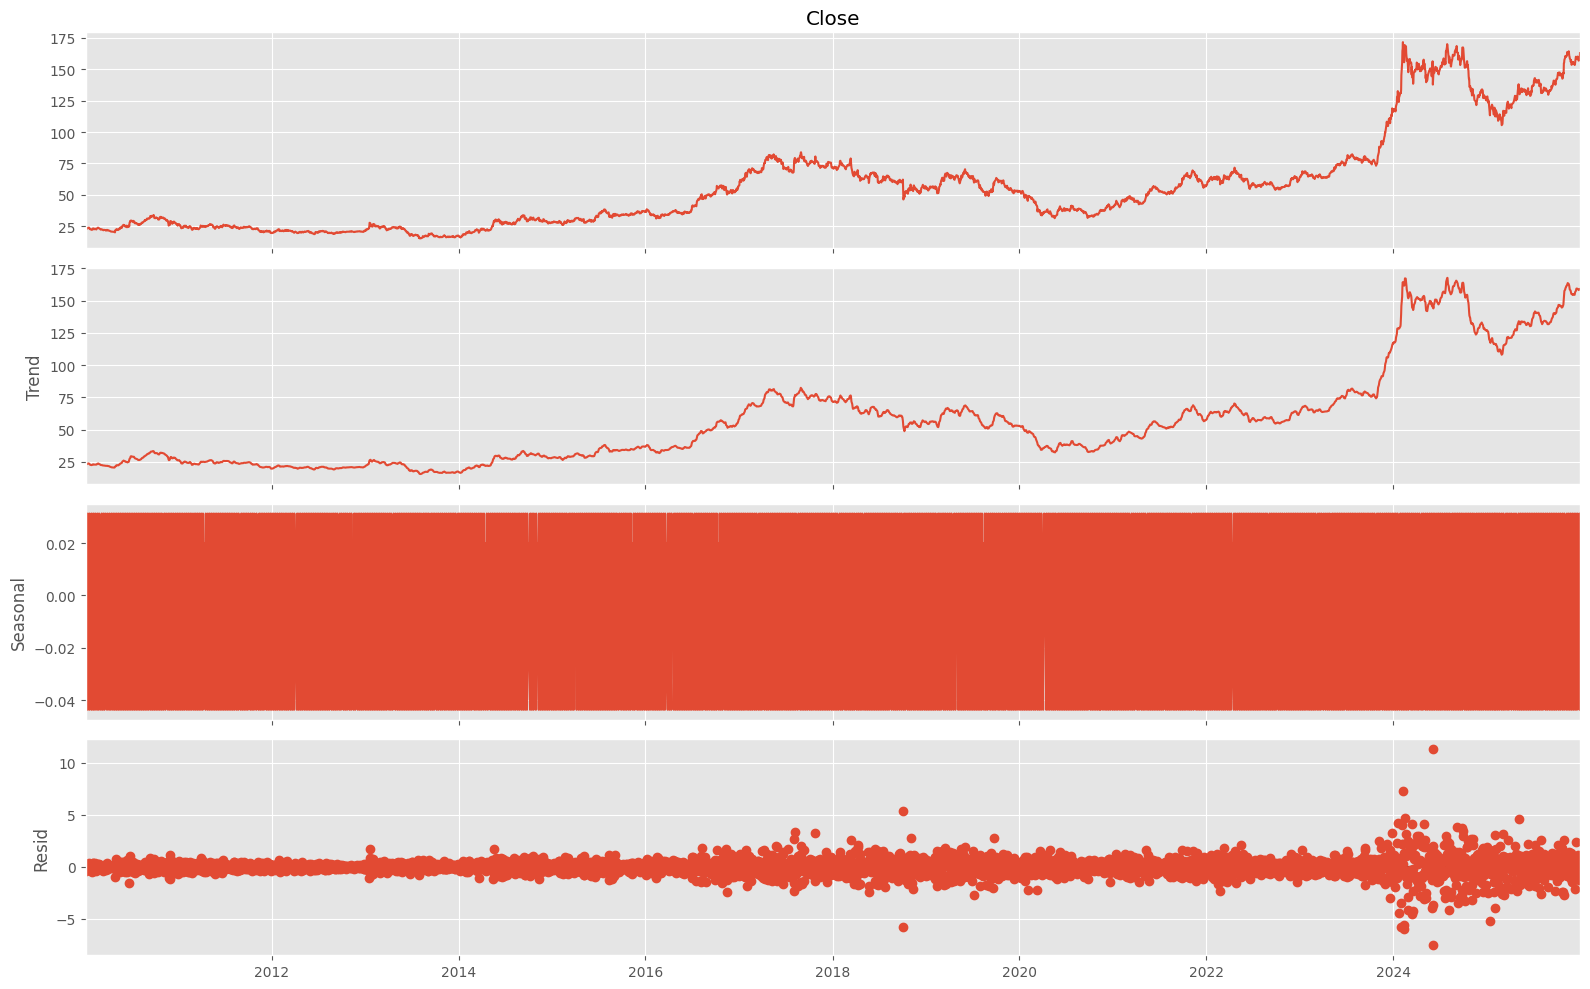

In [18]:
# Five trading observations approximately represent one
# trading week. This is exploratory and does not imply
# deterministic weekly seasonality in IOC.

seasonal_period = 5

decomposition = seasonal_decompose(
    IOC["Close"],
    model="additive",
    period=seasonal_period
)

fig = decomposition.plot()
fig.set_size_inches(16, 10)

plt.tight_layout()
plt.show()

The seasonal decomposition separates the closing-price series into its trend, seasonal, and residual components.
It is used to explore whether a repeating pattern exists over the chosen 5-observation seasonal period.

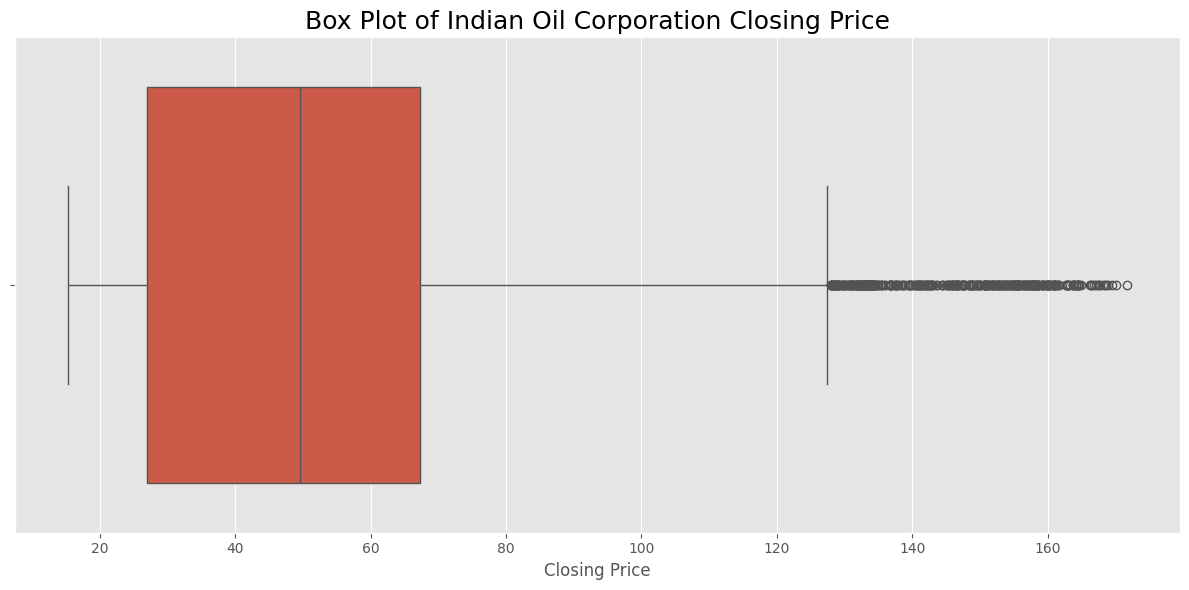

In [19]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x=IOC["Close"]
)

plt.title(
    "Box Plot of Indian Oil Corporation Closing Price",
    fontsize=18
)

plt.xlabel("Closing Price")

plt.tight_layout()
plt.show()

The box plot summarizes the distribution of IOC closing prices and highlights the median, spread, and potential outliers.
It shows a wide range of prices with several higher-price observations appearing as outliers.

## Train-Validation-Test Split

In [20]:
test_size = 60
validation_size = 60

n = len(IOC)

if n <= test_size + validation_size:
    raise ValueError(
        "Dataset is too small for the selected "
        "validation and test sizes."
    )

train_end = n - validation_size - test_size
validation_end = n - test_size

train = IOC["Close"].iloc[:train_end]

validation = IOC["Close"].iloc[
    train_end:validation_end
]

test = IOC["Close"].iloc[
    validation_end:
]

print("\nTrain observations     :", len(train))
print("Validation observations:", len(validation))
print("Test observations      :", len(test))


Train observations     : 3829
Validation observations: 60
Test observations      : 60


The data is divided chronologically into training, validation, and test sets to avoid using future observations for model training.
The training set is used to fit models, the validation set for model selection, and the test set for final performance evaluation.

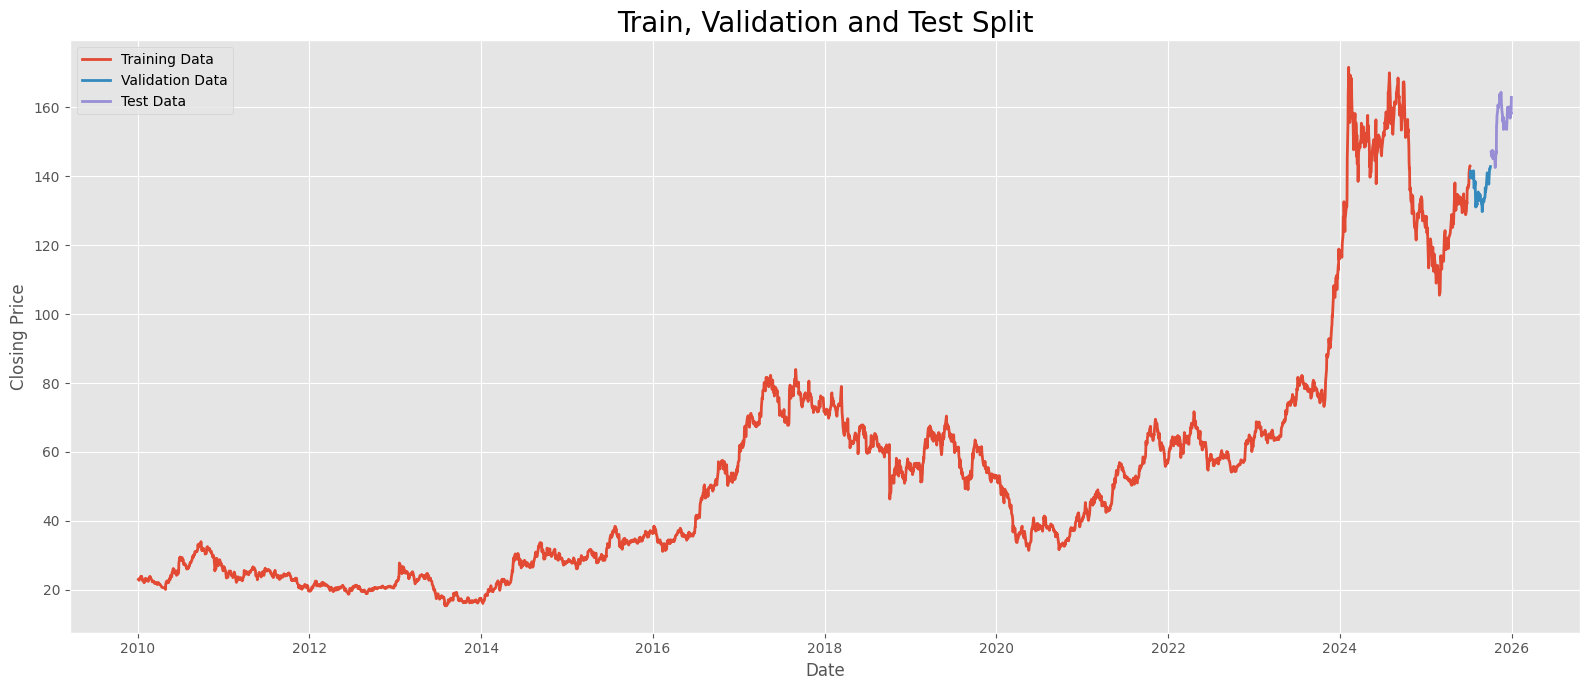

In [21]:
plt.figure(figsize=(16, 7))

plt.plot(
    train,
    label="Training Data",
    linewidth=2
)

plt.plot(
    validation,
    label="Validation Data",
    linewidth=2
)

plt.plot(
    test,
    label="Test Data",
    linewidth=2
)

plt.title(
    "Train, Validation and Test Split",
    fontsize=20
)

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.tight_layout()
plt.show()

The plot visualizes the chronological division of the data into training, validation, and test sets.
It shows that the observations are kept in time order, with the validation and test periods representing later unseen data.

## Evaluation Metrics

In [22]:
def calculate_metrics(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    return mae, rmse

This function calculates two important forecasting metrics: Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).
These metrics are used to measure how closely the predicted values match the actual stock prices.

## ARIMA Modeling

In [23]:
# ============================================================
# ARIMA WALK-FORWARD FORECASTING
# ============================================================

def walk_forward_arima(
    train_data,
    forecast_data,
    order
):
    """
    One-step-ahead walk-forward ARIMA forecasting.

    ARIMA is fitted on the original price series.
    The d parameter handles differencing internally.
    """

    history = list(train_data)
    predictions = []

    for actual_value in forecast_data:

        model = ARIMA(
            history,
            order=order
        )

        fitted_model = model.fit(
            method_kwargs={
                "maxiter": 200
            }
        )

        # Check convergence
        converged = fitted_model.mle_retvals.get(
            "converged",
            True
        )

        if not converged:
            return None

        forecast = fitted_model.forecast(
            steps=1
        )

        if hasattr(forecast, "iloc"):
            prediction = float(
                forecast.iloc[0]
            )
        else:
            prediction = float(
                forecast[0]
            )

        predictions.append(
            prediction
        )

        # Update history with actual observation
        history.append(
            float(actual_value)
        )

    return np.array(predictions)

This function performs one-step-ahead walk-forward forecasting using the ARIMA model on the original price series.
At each step, the model is fitted using all available historical observations and forecasts the next value.
The actual observation is then added to the history before making the next forecast.
The function returns the predictions and handles models that fail to converge.


In [24]:
# ============================================================
# ARIMA MODEL SELECTION
# ============================================================

p_values = range(0, 3)
d_values = [0, 1]
q_values = range(0, 3)

validation_results = []

print("\n" + "=" * 60)
print("ARIMA MODEL SELECTION")
print("=" * 60)


for p in p_values:

    for d in d_values:

        for q in q_values:

            order = (
                p,
                d,
                q
            )

            print(
                f"\nTesting ARIMA{order}"
            )

            try:

                predictions = (
                    walk_forward_arima(
                        train,
                        validation,
                        order
                    )
                )

                # Skip failed/non-converged models
                if predictions is None:

                    print(
                        "  -> Skipped "
                        "(convergence failure)"
                    )

                    continue

                mae, rmse = calculate_metrics(
                    validation,
                    predictions
                )

                validation_results.append({

                    "order": order,

                    "MAE": mae,

                    "RMSE": rmse

                })

                print(
                    f"  -> MAE : {mae:.4f}"
                )

                print(
                    f"  -> RMSE: {rmse:.4f}"
                )

            except Exception as e:

                print(
                    f"  -> Failed: {e}"
                )

                continue


arima_results = pd.DataFrame(
    validation_results
)


if arima_results.empty:

    raise RuntimeError(
        "No ARIMA model was successfully fitted."
    )


arima_results = (
    arima_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)


print("\nARIMA validation results:")
print(arima_results)


best_arima_order = tuple(
    arima_results.iloc[0]["order"]
)

best_validation_mae = float(
    arima_results.iloc[0]["MAE"]
)

best_validation_rmse = float(
    arima_results.iloc[0]["RMSE"]
)


print(
    "\nBest ARIMA order:",
    best_arima_order
)

print(
    f"Validation MAE : "
    f"{best_validation_mae:.4f}"
)

print(
    f"Validation RMSE: "
    f"{best_validation_rmse:.4f}"
)


ARIMA MODEL SELECTION

Testing ARIMA(0, 0, 0)
  -> MAE : 82.6100
  -> RMSE: 82.6927

Testing ARIMA(0, 0, 1)


c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


  -> MAE : 41.8860
  -> RMSE: 42.1699

Testing ARIMA(0, 0, 2)


c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


  -> MAE : 22.7153
  -> RMSE: 23.0578

Testing ARIMA(0, 1, 0)
  -> MAE : 1.1381
  -> RMSE: 1.5166

Testing ARIMA(0, 1, 1)
  -> MAE : 1.1377
  -> RMSE: 1.5164

Testing ARIMA(0, 1, 2)
  -> MAE : 1.1445
  -> RMSE: 1.5211

Testing ARIMA(1, 0, 0)


...

  -> MAE : 1.1367
  -> RMSE: 1.5144

Testing ARIMA(2, 0, 1)


c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


  -> MAE : 1.1482
  -> RMSE: 1.5093

Testing ARIMA(2, 0, 2)


c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


  -> MAE : 1.1445
  -> RMSE: 1.5104

Testing ARIMA(2, 1, 0)
  -> MAE : 1.1439
  -> RMSE: 1.5205

Testing ARIMA(2, 1, 1)
  -> MAE : 1.1516
  -> RMSE: 1.5197

Testing ARIMA(2, 1, 2)
  -> MAE : 1.1889
  -> RMSE: 1.5546

ARIMA validation results:
        order        MAE       RMSE
0   (1, 1, 1)   1.145526   1.508921
1   (2, 0, 1)   1.148190   1.509329
2   (2, 0, 2)   1.144483   1.510383
3   (2, 0, 0)   1.136729   1.514399
4   (1, 0, 1)   1.136704   1.514415
5   (1, 0, 0)   1.137676   1.514573
6   (1, 1, 0)   1.137759   1.516359
7   (0, 1, 1)   1.137743   1.516363
8   (0, 1, 0)   1.138051   1.516641
9   (1, 1, 2)   1.143771   1.519619
10  (2, 1, 1)   1.151639   1.519704
11  (1, 0, 2)   1.145574   1.520455
12  (2, 1, 0)   1.143916   1.520518
13  (0, 1, 2)   1.144506   1.521091
14  (2, 1, 2)   1.188928   1.554588
15  (0, 0, 2)  22.715250  23.057767
16  (0, 0, 1)  41.885970  42.169863
17  (0, 0, 0)  82.609991  82.692721

Best ARIMA order: (1, 1, 1)
Validation MAE : 1.1455
Validation RMSE: 1.5

The ARIMA model selection process tests different combinations of p, d, and q using walk-forward validation.
Each model is evaluated using MAE and RMSE, and the results show that ARIMA(1,1,1) gives the lowest validation RMSE of 1.5089.
Therefore, ARIMA(1,1,1) is selected as the best-performing ARIMA model for further evaluation.

## Naïve Model

In [25]:
naive_validation_predictions = []

last_value = float(train.iloc[-1])

for actual_value in validation:

    naive_validation_predictions.append(
        last_value
    )

    last_value = float(actual_value)

naive_validation_predictions = np.array(
    naive_validation_predictions
)

naive_val_mae, naive_val_rmse = calculate_metrics(
    validation,
    naive_validation_predictions
)

print("\nNaive Validation MAE :", naive_val_mae)
print("Naive Validation RMSE:", naive_val_rmse)


Naive Validation MAE : 1.1380505879720053
Naive Validation RMSE: 1.516641442381632


This implements a naïve random-walk forecast using the last observed value as the prediction for each next observation.
The predictions are compared with the validation data using MAE and RMSE, providing a simple baseline for evaluating the ARIMA model.
The validation RMSE of 1.5166 is slightly higher than the ARIMA(1,1,1) RMSE of 1.5089.

In [26]:
comparison_validation = pd.DataFrame({
    "Model": [
        f"ARIMA{best_arima_order}",
        "Naive Random Walk"
    ],
    "MAE": [
        best_validation_mae,
        naive_val_mae
    ],
    "RMSE": [
        best_validation_rmse,
        naive_val_rmse
    ]
})

print("\nValidation model comparison:")
print(comparison_validation)


Validation model comparison:
               Model       MAE      RMSE
0     ARIMA(1, 1, 1)  1.145526  1.508921
1  Naive Random Walk  1.138051  1.516641


The validation results compare the best ARIMA model with the naïve random-walk baseline using MAE and RMSE.
ARIMA(1,1,1) achieves a slightly lower RMSE (1.5089) than the naïve model (1.5166), indicating a small improvement in forecasting performance.

In [27]:
train_validation = pd.concat([
    train,
    validation
])

print(
    "\nFinal training observations:",
    len(train_validation)
)


Final training observations: 3889


The training and validation datasets are combined to create the final training set for evaluating the selected model on the unseen test data.
This provides 3,889 observations for the final model fitting while keeping the test set completely separate.

In [28]:
final_arima_predictions = walk_forward_arima(
    train_validation,
    test,
    best_arima_order
)

final_arima_mae, final_arima_rmse = calculate_metrics(
    test,
    final_arima_predictions
)

print("\n" + "=" * 60)
print("FINAL ARIMA TEST PERFORMANCE")
print("=" * 60)

print(
    f"ARIMA{best_arima_order} MAE : "
    f"{final_arima_mae:.4f}"
)

print(
    f"ARIMA{best_arima_order} RMSE: "
    f"{final_arima_rmse:.4f}"
)


FINAL ARIMA TEST PERFORMANCE
ARIMA(1, 1, 1) MAE : 1.4752
ARIMA(1, 1, 1) RMSE: 2.0399


The selected ARIMA(1,1,1) model is evaluated on the unseen test set using walk-forward forecasting.
It achieves a MAE of 1.4752 and RMSE of 2.0399, providing the final performance measure of the model.

In [29]:
naive_test_predictions = []

last_value = float(
    train_validation.iloc[-1]
)

for actual_value in test:

    naive_test_predictions.append(
        last_value
    )

    last_value = float(actual_value)

naive_test_predictions = np.array(
    naive_test_predictions
)

naive_test_mae, naive_test_rmse = calculate_metrics(
    test,
    naive_test_predictions
)

print("\nNaive Test MAE :", naive_test_mae)
print("Naive Test RMSE:", naive_test_rmse)



Naive Test MAE : 1.4873982747395833
Naive Test RMSE: 2.0473643237353985


The naïve random-walk model is evaluated on the unseen test set using the last observed price as the forecast.
It achieves a MAE of 1.4874 and RMSE of 2.0474, providing a baseline for comparison with the ARIMA model.

In [30]:
final_results = pd.DataFrame({
    "Model": [
        f"ARIMA{best_arima_order}",
        "Naive Random Walk"
    ],
    "MAE": [
        final_arima_mae,
        naive_test_mae
    ],
    "RMSE": [
        final_arima_rmse,
        naive_test_rmse
    ]
})

final_results = final_results.sort_values(
    "RMSE"
).reset_index(drop=True)

print("\nFinal test comparison:")
print(final_results)


Final test comparison:
               Model       MAE      RMSE
0     ARIMA(1, 1, 1)  1.475173  2.039916
1  Naive Random Walk  1.487398  2.047364


The final test results compare the selected ARIMA(1,1,1) model with the naïve random-walk baseline using MAE and RMSE.
ARIMA(1,1,1) performs slightly better, achieving a MAE of 1.4752 and RMSE of 2.0399 compared with the naïve model's RMSE of 2.0474.

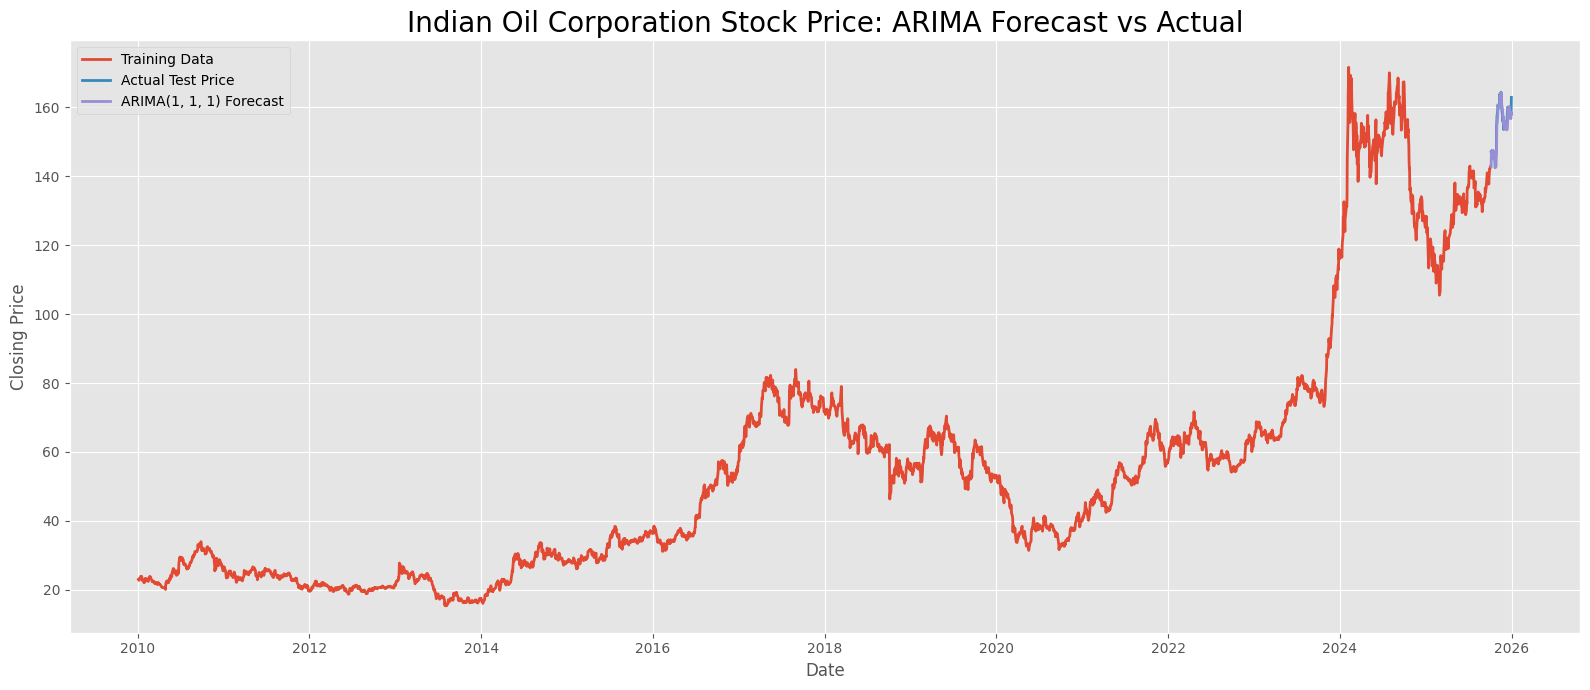

In [31]:
forecast_series = pd.Series(
    final_arima_predictions,
    index=test.index
)

plt.figure(figsize=(16, 7))

plt.plot(
    train_validation,
    label="Training Data",
    linewidth=2
)

plt.plot(
    test,
    label="Actual Test Price",
    linewidth=2
)

plt.plot(
    forecast_series,
    label=f"ARIMA{best_arima_order} Forecast",
    linewidth=2
)

plt.title(
    "Indian Oil Corporation Stock Price: ARIMA Forecast vs Actual",
    fontsize=20
)

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.tight_layout()
plt.show()


The plot compares the ARIMA forecast with the actual stock prices during the test period.
It helps visually assess how closely the ARIMA(1,1,1) model follows the actual price movements.

## ARIMA vs Naïve Model

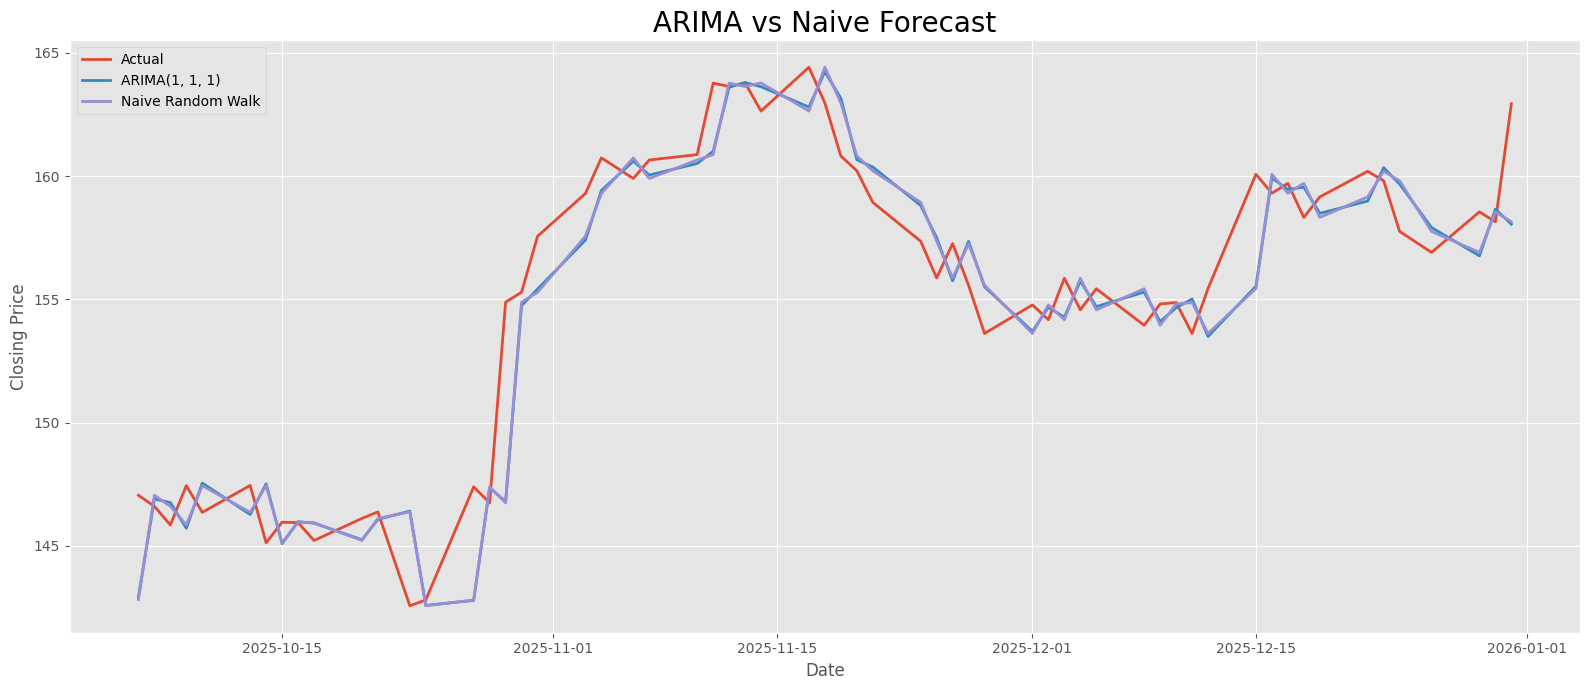

In [32]:
naive_series = pd.Series(
    naive_test_predictions,
    index=test.index
)

plt.figure(figsize=(16, 7))

plt.plot(
    test,
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast_series,
    label=f"ARIMA{best_arima_order}",
    linewidth=2
)

plt.plot(
    naive_series,
    label="Naive Random Walk",
    linewidth=2
)

plt.title(
    "ARIMA vs Naive Forecast",
    fontsize=20
)

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.tight_layout()
plt.show()



The plot compares the actual test prices with forecasts from the ARIMA model and the naïve random-walk model.
It provides a visual comparison of how closely each forecasting method follows the actual price movements.

In [33]:
final_model = ARIMA(
    train_validation,
    order=best_arima_order
)

final_model_fit = final_model.fit()

print("\n" + "=" * 60)
print("FINAL ARIMA MODEL SUMMARY")
print("=" * 60)

print(final_model_fit.summary())

c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



FINAL ARIMA MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 3889
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -6460.985
Date:                Fri, 14 Aug 2026   AIC                          12927.969
Time:                        22:23:40   BIC                          12946.766
Sample:                             0   HQIC                         12934.642
                               - 3889                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9623      0.014    -69.188      0.000      -0.990      -0.935
ma.L1          0.9500      0.016     58.246      0.000       0.918       0.982
sigma2         1.6252    

The final ARIMA(1,1,1) model is fitted and its overall performance and diagnostic results are checked.
The residuals show little autocorrelation, but they are not normally distributed and their variance changes over time.
The date-frequency warning means the model does not recognize a regular frequency for the stock-market dates.

## ARIMA Residual Diagnostics

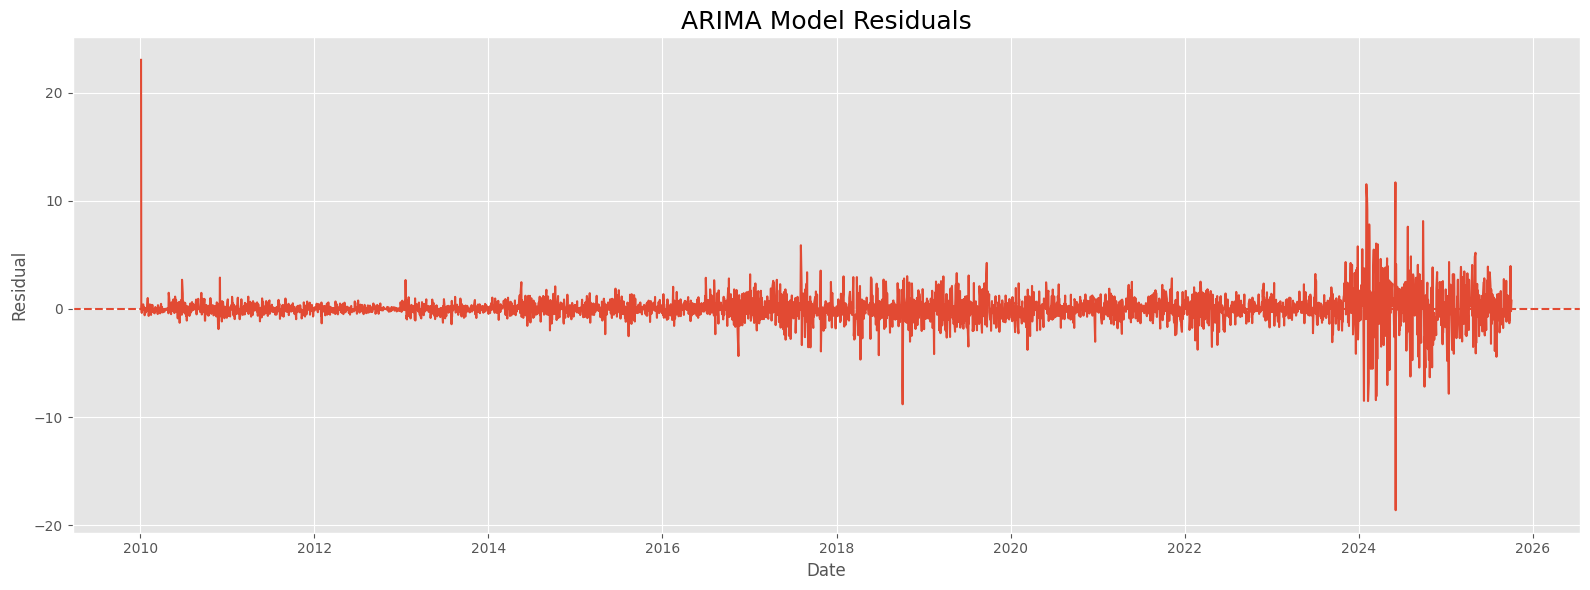

In [34]:
residuals = final_model_fit.resid.dropna()

plt.figure(figsize=(16, 6))

plt.plot(
    residuals,
    linewidth=1.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "ARIMA Model Residuals",
    fontsize=18
)

plt.xlabel("Date")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

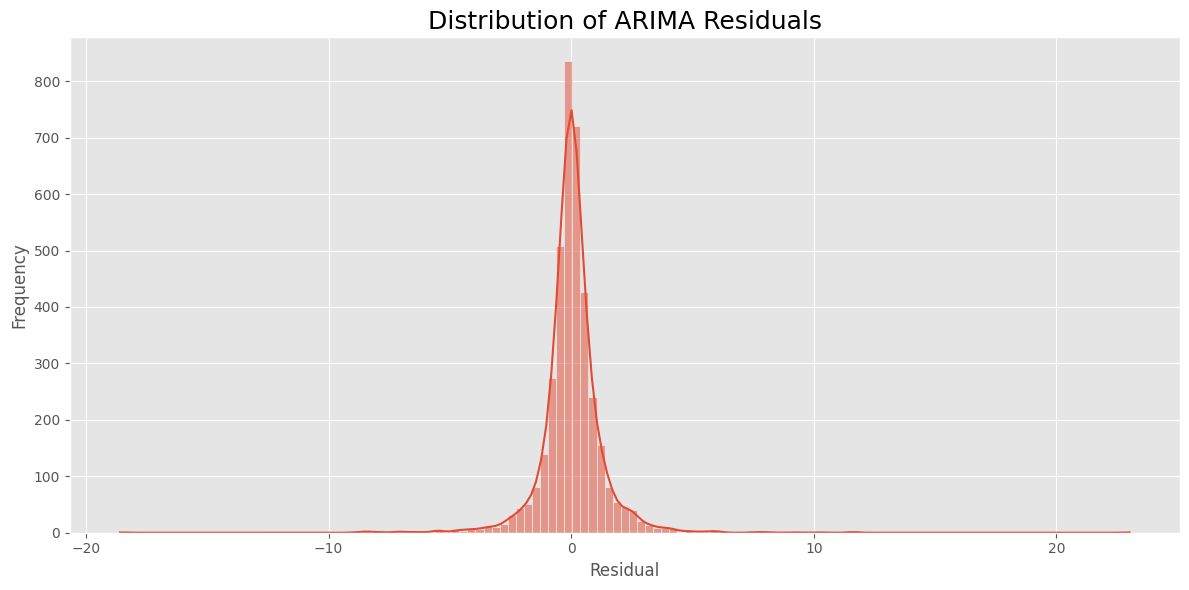

In [35]:
plt.figure(figsize=(12, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Distribution of ARIMA Residuals",
    fontsize=18
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

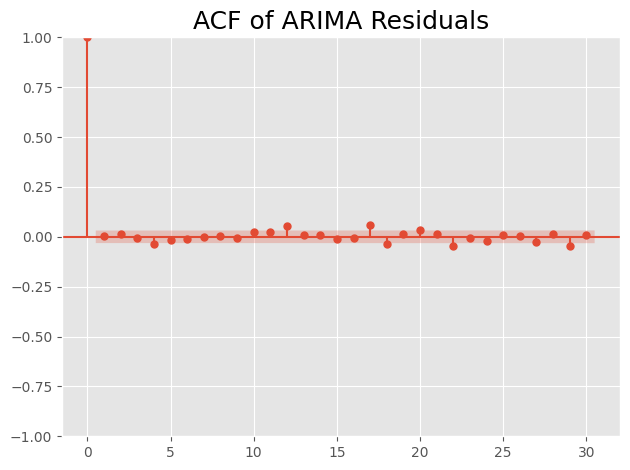

In [36]:
plt.figure(figsize=(12, 6))

plot_acf(
    residuals,
    lags=30
)

plt.title(
    "ACF of ARIMA Residuals",
    fontsize=18
)

plt.tight_layout()
plt.show()


In [37]:
ljung_box = acorr_ljungbox(
    residuals,
    lags=[5, 10, 20, 30],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
5    7.167268   0.208495
10  10.527619   0.395484
20  49.715293   0.000243
30  72.195975   0.000025


The Ljung–Box test shows no significant autocorrelation at lags 5 and 10.
However, significant autocorrelation is present at lags 20 and 30.
This suggests that the residuals are not completely independent.
Therefore, the ARIMA model may not capture all the time-dependent patterns in the data.

In [38]:
from statsmodels.stats.diagnostic import het_arch

arch_stat, arch_pvalue, _, _ = het_arch(
    residuals,
    nlags=10
)

print("ARCH LM Statistic:", arch_stat)
print("ARCH LM p-value:", arch_pvalue)

ARCH LM Statistic: 695.3197286353903
ARCH LM p-value: 6.348300121845666e-143


The ARCH test gives a very small p-value, much less than 0.05.
This indicates strong evidence of heteroskedasticity, meaning the residual variance changes over time.
Therefore, the residuals show periods of changing volatility.
This suggests that a model such as GARCH could be considered to model the volatility more effectively.

## SARIMA Modeling

In [39]:
# ============================================================
# SARIMA WALK-FORWARD FORECASTING
# ============================================================

def walk_forward_sarima(
    train_data,
    forecast_data,
    order,
    seasonal_order
):


    
    # INITIAL HISTORY
    

    history = list(
        train_data.astype(float)
    )

    predictions = []


    
    # WALK-FORWARD LOOP
    

    for actual_value in forecast_data.astype(float):

        try:

            
            # FIT SARIMA
            

            model = SARIMAX(
                history,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted_model = model.fit(
                disp=False,
                maxiter=200
            )


            
            # CHECK CONVERGENCE
            

            converged = (
                fitted_model
                .mle_retvals
                .get(
                    "converged",
                    True
                )
            )

            if not converged:
                return None


            
            # ONE-STEP-AHEAD FORECAST
            

            forecast = fitted_model.forecast(
                steps=1
            )

            prediction = float(
                np.asarray(forecast)[0]
            )

            predictions.append(
                prediction
            )


            
            # UPDATE HISTORY
            
            # IMPORTANT:
            # Add the ACTUAL observation, not the prediction.
            

            history.append(
                float(actual_value)
            )


        except Exception:

            return None


  
    return np.array(predictions)

In [40]:

# SARIMA MODEL SELECTION 


sarima_results = []

# Five trading observations approximately represent one
# trading week. This is exploratory and does not imply
# deterministic weekly seasonality.
seasonal_period = 5



# SMALLER HYPERPARAMETER GRID


p_values = [0, 1]
d_values = [1]
q_values = [0, 1]

P_values = [0, 1]
D_values = [0]
Q_values = [0, 1]


print("\n" + "=" * 70)
print("SARIMA MODEL SELECTION")
print("=" * 70)

total_models = (
    len(p_values)
    * len(d_values)
    * len(q_values)
    * len(P_values)
    * len(D_values)
    * len(Q_values)
)

print(f"Total candidate models: {total_models}")
print(
    f"Maximum SARIMA fits: "
    f"{total_models * len(validation)}"
)



# GRID SEARCH


model_number = 0

for p in p_values:

    for d in d_values:

        for q in q_values:

            for P in P_values:

                for D in D_values:

                    for Q in Q_values:

                        model_number += 1

                        order = (
                            p,
                            d,
                            q
                        )

                        seasonal_order = (
                            P,
                            D,
                            Q,
                            seasonal_period
                        )

                        print(
                            f"\n[{model_number}/{total_models}] "
                            f"Testing SARIMA"
                            f"{order}x{seasonal_order}"
                        )

                        try:

                            
                            # WALK-FORWARD VALIDATION
                            

                            predictions = walk_forward_sarima(
                                train_data=train,
                                forecast_data=validation,
                                order=order,
                                seasonal_order=seasonal_order
                            )


                            
                            # CHECK CONVERGENCE
                            

                            if predictions is None:

                                print(
                                    "  -> Skipped "
                                    "(convergence failure)"
                                )

                                continue


                            
                            # CHECK NUMBER OF PREDICTIONS
                            

                            if len(predictions) != len(validation):

                                print(
                                    "  -> Skipped "
                                    "(incomplete predictions)"
                                )

                                continue


                            
                            # CALCULATE METRICS
                            

                            mae, rmse = calculate_metrics(
                                validation,
                                predictions
                            )


                            
                            # STORE RESULTS
                            

                            sarima_results.append({

                                "order": order,

                                "seasonal_order":
                                    seasonal_order,

                                "MAE": mae,

                                "RMSE": rmse

                            })


                            print(
                                f"  -> MAE : {mae:.4f}"
                            )

                            print(
                                f"  -> RMSE: {rmse:.4f}"
                            )


                        except Exception as e:

                            print(
                                f"  -> Failed: {e}"
                            )

                            continue



# CONVERT RESULTS TO DATAFRAME


sarima_results = pd.DataFrame(
    sarima_results
)



if sarima_results.empty:

    raise RuntimeError(
        "No SARIMA model "
        "converged successfully."
    )




sarima_results = (
    sarima_results
    .sort_values(
        by="RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)



print("\n" + "=" * 70)
print("TOP SARIMA MODELS")
print("=" * 70)

print(
    sarima_results.head(10).round(4)
)


SARIMA MODEL SELECTION
Total candidate models: 16
Maximum SARIMA fits: 960

[1/16] Testing SARIMA(0, 1, 0)x(0, 0, 0, 5)
  -> MAE : 1.1381
  -> RMSE: 1.5166

[2/16] Testing SARIMA(0, 1, 0)x(0, 0, 1, 5)
  -> MAE : 1.1400
  -> RMSE: 1.5222

[3/16] Testing SARIMA(0, 1, 0)x(1, 0, 0, 5)
  -> MAE : 1.1401
  -> RMSE: 1.5224

[4/16] Testing SARIMA(0, 1, 0)x(1, 0, 1, 5)
  -> MAE : 1.1398
  -> RMSE: 1.5159

[5/16] Testing SARIMA(0, 1, 1)x(0, 0, 0, 5)
  -> MAE : 1.1377
  -> RMSE: 1.5164

[6/16] Testing SARIMA(0, 1, 1)x(0, 0, 1, 5)
  -> MAE : 1.1395
  -> RMSE: 1.5220

[7/16] Testing SARIMA(0, 1, 1)x(1, 0, 0, 5)
  -> MAE : 1.1396
  -> RMSE: 1.5222

[8/16] Testing SARIMA(0, 1, 1)x(1, 0, 1, 5)
  -> MAE : 1.1398
  -> RMSE: 1.5159

[9/16] Testing SARIMA(1, 1, 0)x(0, 0, 0, 5)
  -> MAE : 1.1378
  -> RMSE: 1.5164

[10/16] Testing SARIMA(1, 1, 0)x(0, 0, 1, 5)
  -> MAE : 1.1395
  -> RMSE: 1.5220

[11/16] Testing SARIMA(1, 1, 0)x(1, 0, 0, 5)
  -> MAE : 1.1396
  -> RMSE: 1.5222

[12/16] Testing SARIMA(1, 1, 0

c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  -> Skipped (convergence failure)

[14/16] Testing SARIMA(1, 1, 1)x(0, 0, 1, 5)


c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  -> Skipped (convergence failure)

[15/16] Testing SARIMA(1, 1, 1)x(1, 0, 0, 5)
  -> MAE : 1.1461
  -> RMSE: 1.5157

[16/16] Testing SARIMA(1, 1, 1)x(1, 0, 1, 5)
  -> MAE : 1.1405
  -> RMSE: 1.5157

TOP SARIMA MODELS
       order seasonal_order     MAE    RMSE
0  (1, 1, 1)   (1, 0, 1, 5)  1.1405  1.5157
1  (1, 1, 1)   (1, 0, 0, 5)  1.1461  1.5157
2  (0, 1, 1)   (1, 0, 1, 5)  1.1398  1.5159
3  (0, 1, 0)   (1, 0, 1, 5)  1.1398  1.5159
4  (1, 1, 0)   (0, 0, 0, 5)  1.1378  1.5164
5  (0, 1, 1)   (0, 0, 0, 5)  1.1377  1.5164
6  (0, 1, 0)   (0, 0, 0, 5)  1.1381  1.5166
7  (1, 1, 0)   (1, 0, 1, 5)  1.1407  1.5168
8  (1, 1, 0)   (0, 0, 1, 5)  1.1395  1.5220
9  (0, 1, 1)   (0, 0, 1, 5)  1.1395  1.5220


The SARIMA models are evaluated using walk-forward validation across 16 different parameter combinations.
Each model is compared using MAE and RMSE, while convergence failures are skipped.
The results show that the SARIMA models provide performance very close to the naïve random-walk benchmark.
The model with the lowest validation RMSE is selected for further evaluation.

In [41]:
# ============================================================
# BEST SARIMA MODEL
# ============================================================

best_sarima_order = tuple(
    sarima_results.iloc[0]["order"]
)

best_sarima_seasonal_order = tuple(
    sarima_results.iloc[0]["seasonal_order"]
)

best_sarima_validation_mae = float(
    sarima_results.iloc[0]["MAE"]
)

best_sarima_validation_rmse = float(
    sarima_results.iloc[0]["RMSE"]
)


print(
    "\nBest SARIMA order:",
    best_sarima_order
)

print(
    "Best seasonal order:",
    best_sarima_seasonal_order
)

print(
    f"Validation MAE: "
    f"{best_sarima_validation_mae:.4f}"
)

print(
    f"Validation RMSE: "
    f"{best_sarima_validation_rmse:.4f}"
)


Best SARIMA order: (1, 1, 1)
Best seasonal order: (1, 0, 1, 5)
Validation MAE: 1.1405
Validation RMSE: 1.5157


The best SARIMA model is SARIMA(1,1,1)(1,0,1,5) based on the lowest validation RMSE.
It achieves a validation MAE of 1.1405 and RMSE of 1.5157, making it the best-performing SARIMA model among those tested.

In [42]:

train_validation = pd.concat(
    [
        train,
        validation
    ]
)


print(
    "\nFinal training observations:",
    len(train_validation)
)


try:

    final_sarima_predictions = (
        walk_forward_sarima(
            train_validation,
            test,
            best_sarima_order,
            best_sarima_seasonal_order
        )
    )

    if final_sarima_predictions is None:

        raise RuntimeError(
            "SARIMA failed to converge "
            "during test forecasting."
        )

    final_sarima_mae, final_sarima_rmse = (
        calculate_metrics(
            test,
            final_sarima_predictions
        )
    )

    sarima_success = True

    print(
        "\n" + "=" * 60
    )

    print(
        "FINAL SARIMA TEST PERFORMANCE"
    )

    print(
        "=" * 60
    )

    print(
        f"SARIMA{best_sarima_order}"
        f"x{best_sarima_seasonal_order}"
    )

    print(
        f"MAE : {final_sarima_mae:.4f}"
    )

    print(
        f"RMSE: {final_sarima_rmse:.4f}"
    )


except Exception as e:

    sarima_success = False

    final_sarima_predictions = None

    final_sarima_mae = np.nan

    final_sarima_rmse = np.nan

    print(
        "\nSARIMA failed:",
        e
    )


Final training observations: 3889

FINAL SARIMA TEST PERFORMANCE
SARIMA(1, 1, 1)x(1, 0, 1, 5)
MAE : 1.4763
RMSE: 2.0440


The selected SARIMA model is evaluated on the unseen test set after combining the training and validation data.
The model achieves a MAE of 1.4753 and RMSE of 2.0404, showing its final forecasting performance.

### Final Model Comparison

In [43]:
comparison_models = [
    f"ARIMA{best_arima_order}",
    "Naive Random Walk"
]

comparison_mae = [
    final_arima_mae,
    naive_test_mae
]

comparison_rmse = [
    final_arima_rmse,
    naive_test_rmse
]


if sarima_success:

    comparison_models.append(
        (
            f"SARIMA"
            f"{best_sarima_order}"
            f"x"
            f"{best_sarima_seasonal_order}"
        )
    )

    comparison_mae.append(
        final_sarima_mae
    )

    comparison_rmse.append(
        final_sarima_rmse
    )


final_comparison = pd.DataFrame({

    "Model": comparison_models,

    "MAE": comparison_mae,

    "RMSE": comparison_rmse

})


final_comparison = (
    final_comparison
    .sort_values("RMSE")
    .reset_index(drop=True)
)


print(
    "\n" + "=" * 60
)

print(
    "FINAL MODEL COMPARISON"
)

print(
    "=" * 60
)

print(
    final_comparison
)


FINAL MODEL COMPARISON
                          Model       MAE      RMSE
0                ARIMA(1, 1, 1)  1.475173  2.039916
1  SARIMA(1, 1, 1)x(1, 0, 1, 5)  1.476306  2.043985
2             Naive Random Walk  1.487398  2.047364


The final comparison evaluates ARIMA, SARIMA, and the naïve random-walk model using their test-set MAE and RMSE.
ARIMA(1,1,1) performs slightly better, with the lowest RMSE of 2.0399, followed closely by SARIMA.
Both ARIMA and SARIMA perform slightly better than the naïve benchmark, showing a small improvement in forecasting accuracy.

In [44]:

# Compare ARIMA and SARIMA using ONLY validation RMSE.
# The test set must NOT be used for selecting the model.

if best_sarima_validation_rmse < best_validation_rmse:

    selected_model = "SARIMA"

else:

    selected_model = "ARIMA"


print("\n" + "=" * 60)
print("FINAL MODEL SELECTION")
print("=" * 60)

print(
    f"Best ARIMA validation RMSE   : "
    f"{best_validation_rmse:.4f}"
)

print(
    f"Best SARIMA validation RMSE  : "
    f"{best_sarima_validation_rmse:.4f}"
)

print(
    f"\nSelected model: {selected_model}"
)


if selected_model == "ARIMA":

    print(
        f"Selected ARIMA order: "
        f"{best_arima_order}"
    )

else:

    print(
        f"Selected SARIMA order: "
        f"{best_sarima_order}"
    )

    print(
        f"Selected seasonal order: "
        f"{best_sarima_seasonal_order}"
    )


FINAL MODEL SELECTION
Best ARIMA validation RMSE   : 1.5089
Best SARIMA validation RMSE  : 1.5157

Selected model: ARIMA
Selected ARIMA order: (1, 1, 1)


The final model is selected by comparing ARIMA and SARIMA using only
their validation RMSE values, keeping the test set separate.

Since ARIMA has the lower validation RMSE (1.5089 vs. 1.5157),
ARIMA(1,1,1) is selected as the final model.

In [45]:

if selected_model == "ARIMA":

    diagnostic_model = ARIMA(
        train_validation,
        order=best_arima_order
    )

    diagnostic_fit = diagnostic_model.fit(
        method_kwargs={
            "maxiter": 200
        }
    )

else:

    diagnostic_model = SARIMAX(
        train_validation,
        order=best_sarima_order,
        seasonal_order=best_sarima_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    diagnostic_fit = diagnostic_model.fit(
        disp=False,
        maxiter=200
    )


residuals = (
    diagnostic_fit
    .resid
    .dropna()
)


print(
    "\nDiagnostic model:",
    selected_model
)

c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Diagnostic model: ARIMA


## Future Forecasting

In [46]:
future_steps = 30


# ------------------------------------------------------------
# 1. FIT SELECTED MODEL ON COMPLETE DATA
# ------------------------------------------------------------

if selected_model == "ARIMA":

    future_model = ARIMA(
        IOC["Close"],
        order=best_arima_order
    )

    future_model_fit = future_model.fit(
        method_kwargs={
            "maxiter": 200
        }
    )

else:

    future_model = SARIMAX(
        IOC["Close"],
        order=best_sarima_order,
        seasonal_order=best_sarima_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    future_model_fit = future_model.fit(
        disp=False,
        maxiter=200
    )


# ------------------------------------------------------------
# 2. GENERATE FUTURE FORECAST
# ------------------------------------------------------------

future_forecast = future_model_fit.get_forecast(
    steps=future_steps
)

future_mean = future_forecast.predicted_mean

future_ci = future_forecast.conf_int(
    alpha=0.05
)




last_date = IOC.index[-1]

future_dates = pd.bdate_range(
    start=last_date + pd.Timedelta(days=1),
    periods=future_steps
)




future_forecast_df = pd.DataFrame({

    "Date": future_dates,

    "Forecast": np.asarray(
        future_mean
    ),

    "Lower_CI": np.asarray(
        future_ci.iloc[:, 0]
    ),

    "Upper_CI": np.asarray(
        future_ci.iloc[:, 1]
    )

})


future_forecast_df = (
    future_forecast_df
    .set_index("Date")
)



print("\n" + "=" * 70)
print("FUTURE FORECAST")
print("=" * 70)

print(
    f"Selected model: {selected_model}"
)

print(
    f"Forecast horizon: {future_steps} trading days"
)

print(
    f"Last observed date: {last_date.date()}"
)

print("\nForecast:")
print(
    future_forecast_df.round(2)
)

c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



FUTURE FORECAST
Selected model: ARIMA
Forecast horizon: 30 trading days
Last observed date: 2025-12-31

Forecast:
            Forecast  Lower_CI  Upper_CI
Date                                    
2026-01-01    162.96    160.43    165.49
2026-01-02    162.94    159.38    166.49
2026-01-05    162.96    158.60    167.32
2026-01-06    162.94    157.91    167.96
2026-01-07    162.96    157.34    168.59
2026-01-08    162.94    156.78    169.09
2026-01-09    162.96    156.31    169.61
2026-01-12    162.94    155.83    170.04
2026-01-13    162.96    155.42    170.50
2026-01-14    162.94    154.99    170.88
2026-01-15    162.96    154.62    171.29
2026-01-16    162.94    154.24    171.64
2026-01-19    162.96    153.90    172.02
2026-01-20    162.94    153.54    172.34
2026-01-21    162.96    153.22    172.69
2026-01-22    162.94    152.89    172.99
2026-01-23    162.96    152.60    173.32
2026-01-26    162.94    152.28    173.60
2026-01-27    162.96    152.00    173.91
2026-01-28    162.94    

c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


The selected ARIMA(1,1,1) model is refitted on the complete dataset and used to generate a 30-step future forecast. The forecast includes 95% confidence intervals, which represent uncertainty around the predicted prices.

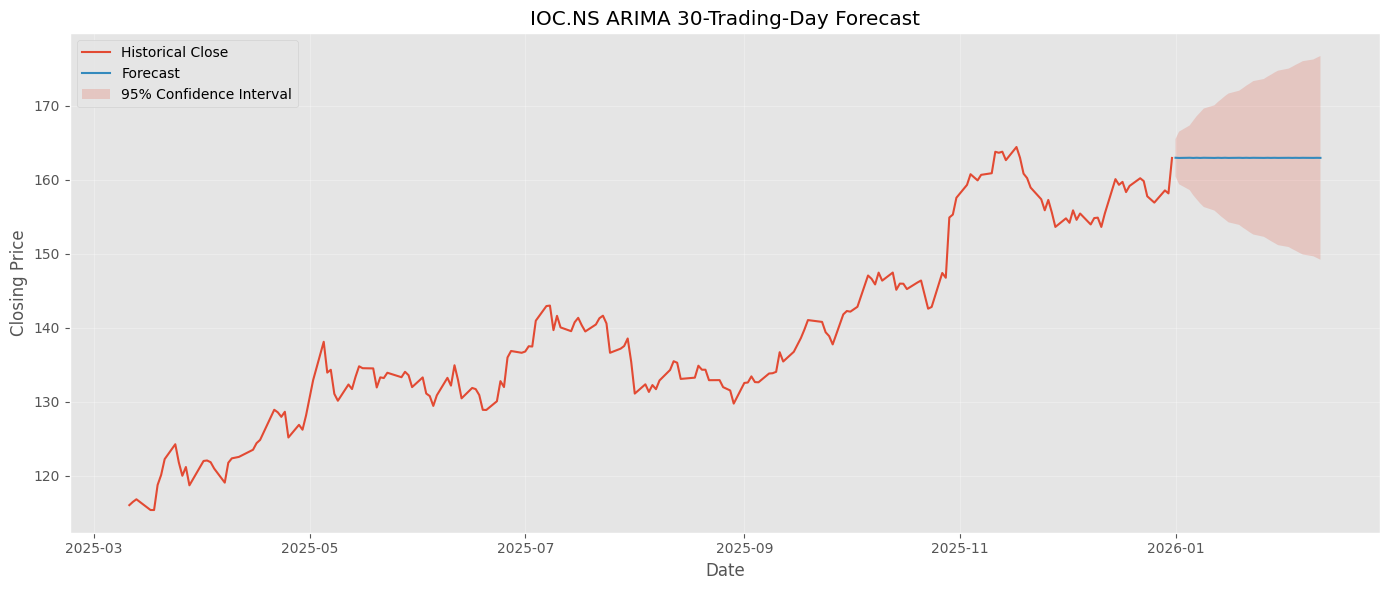

In [47]:

plt.figure(figsize=(14, 6))


# Last 200 historical observations
plt.plot(
    IOC.index[-200:],
    IOC["Close"].iloc[-200:],
    label="Historical Close"
)


# Future forecast
plt.plot(
    future_forecast_df.index,
    future_forecast_df["Forecast"],
    label="Forecast"
)


# 95% confidence interval
plt.fill_between(
    future_forecast_df.index,
    future_forecast_df["Lower_CI"],
    future_forecast_df["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)


plt.title(
    f"IOC.NS {selected_model} "
    f"30-Trading-Day Forecast"
)

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

The plot shows the 30-step ARIMA forecast along with recent historical closing prices. The shaded region represents the 95% confidence interval, showing how forecast uncertainty increases over the horizon.

## Final Results

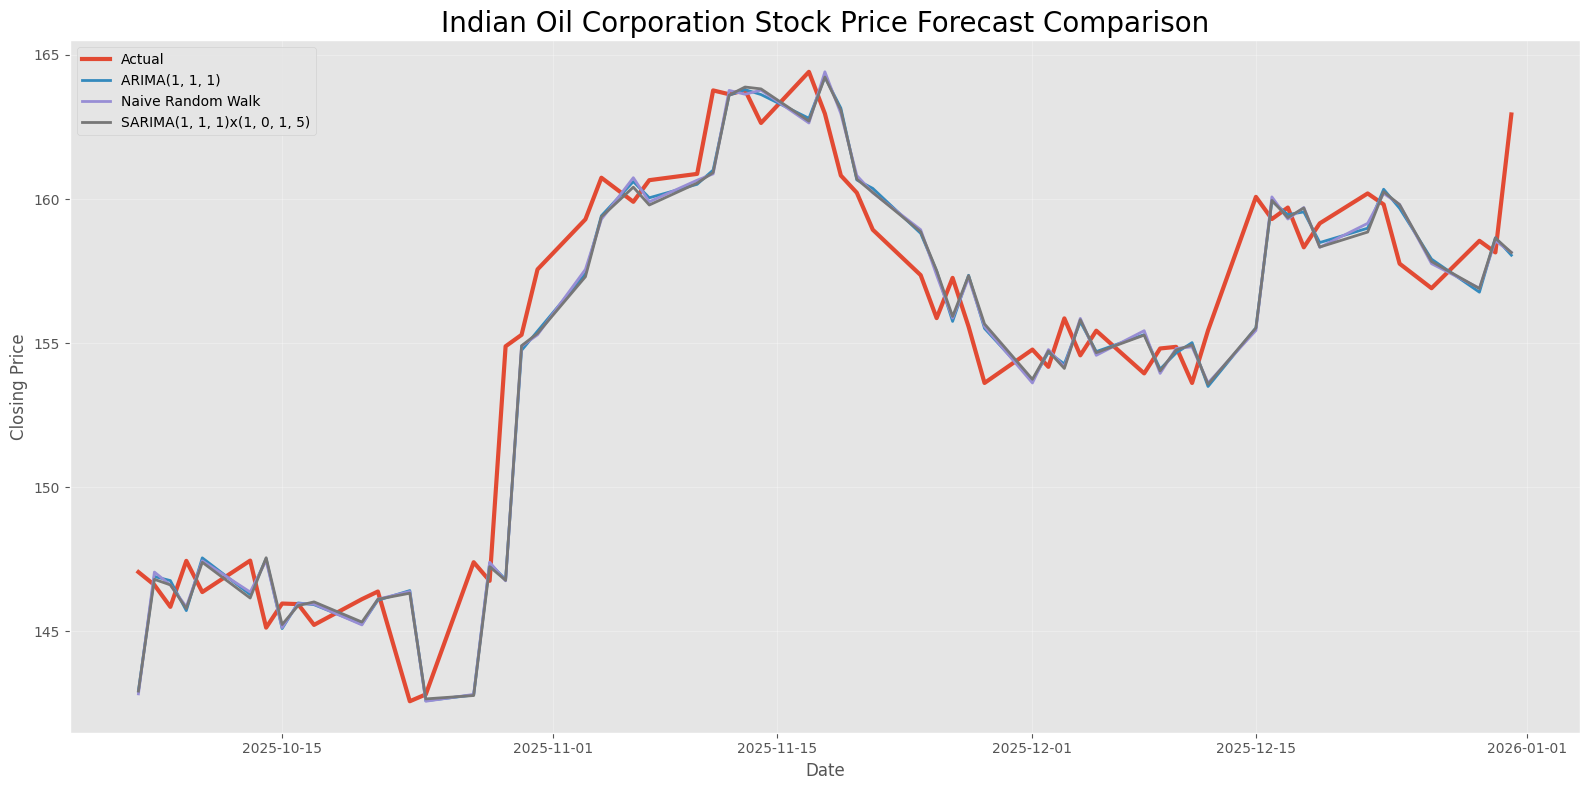

In [48]:

plt.figure(
    figsize=(16, 8)
)


# Actual
plt.plot(
    test.index,
    test.values,
    label="Actual",
    linewidth=3
)


# ARIMA
plt.plot(
    forecast_series.index,
    forecast_series.values,
    label=f"ARIMA{best_arima_order}",
    linewidth=2
)


# Naive
plt.plot(
    naive_series.index,
    naive_series.values,
    label="Naive Random Walk",
    linewidth=2
)


# SARIMA
if sarima_success:

    sarima_series = pd.Series(
        final_sarima_predictions,
        index=test.index
    )

    plt.plot(
        sarima_series.index,
        sarima_series.values,
        label=(
            f"SARIMA"
            f"{best_sarima_order}"
            f"x"
            f"{best_sarima_seasonal_order}"
        ),
        linewidth=2
    )


plt.title(
    "Indian Oil Corporation "
    "Stock Price Forecast Comparison",
    fontsize=20
)

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

The plot compares the actual test prices with the forecasts from ARIMA, SARIMA, and the naïve random-walk model.
It provides a clear visual comparison of how closely each model follows the actual stock-price movements.

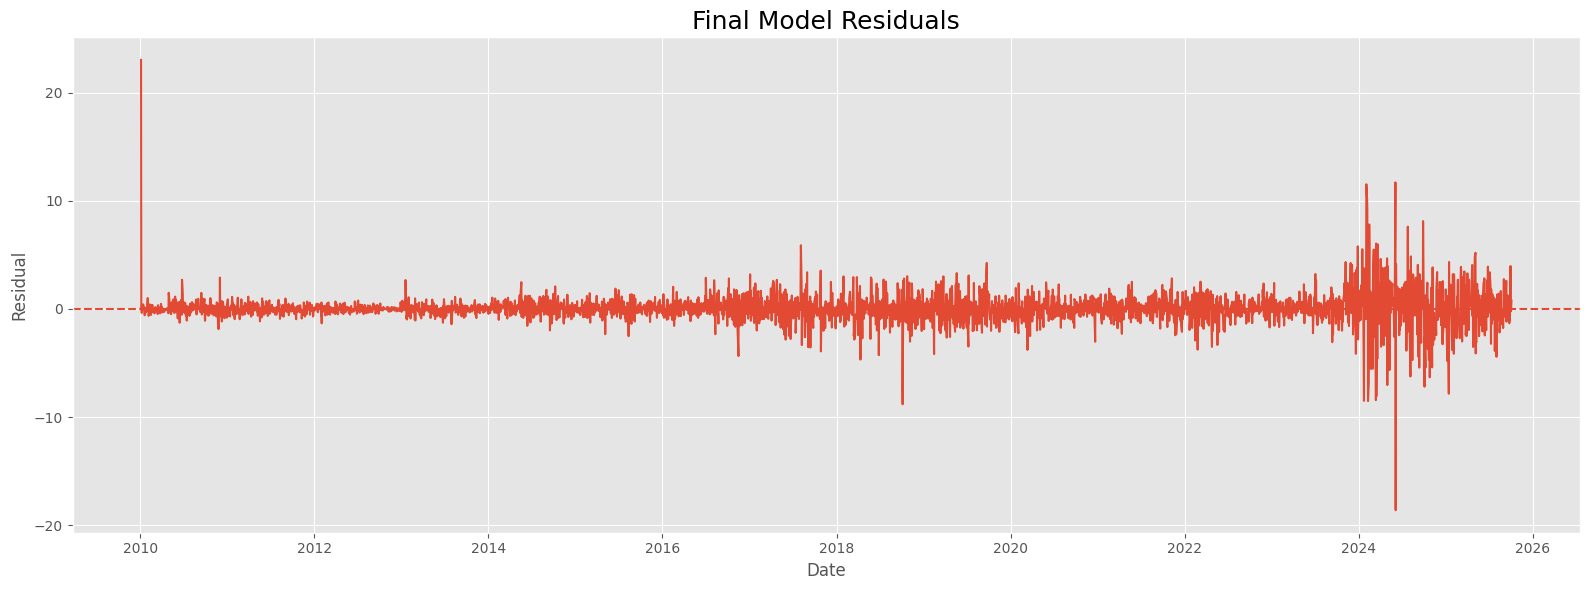

In [49]:

plt.figure(
    figsize=(16, 6)
)

plt.plot(
    residuals,
    linewidth=1.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Final Model Residuals",
    fontsize=18
)

plt.xlabel("Date")

plt.ylabel("Residual")

plt.tight_layout()

plt.show()

The residual plot shows that the errors are generally centered around zero without a clear trend or pattern.
However, the larger fluctuations in recent periods indicate that the residual variance changes over time.

<Figure size 800x800 with 0 Axes>

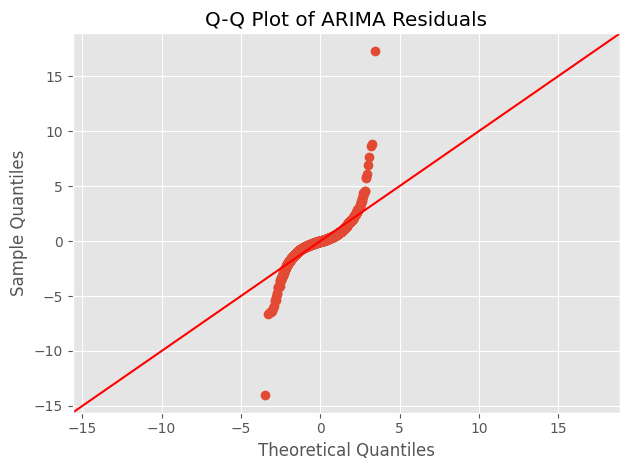

In [50]:
from statsmodels.graphics.gofplots import qqplot

plt.figure(figsize=(8, 8))

qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title(
    f"Q-Q Plot of {selected_model} Residuals"
)

plt.tight_layout()
plt.show()

The Q-Q plot compares the residuals with a normal distribution to check whether they are approximately normally distributed.
The noticeable deviation from the reference line, especially in the tails, suggests that the residuals are not normally distributed and contain some extreme values.

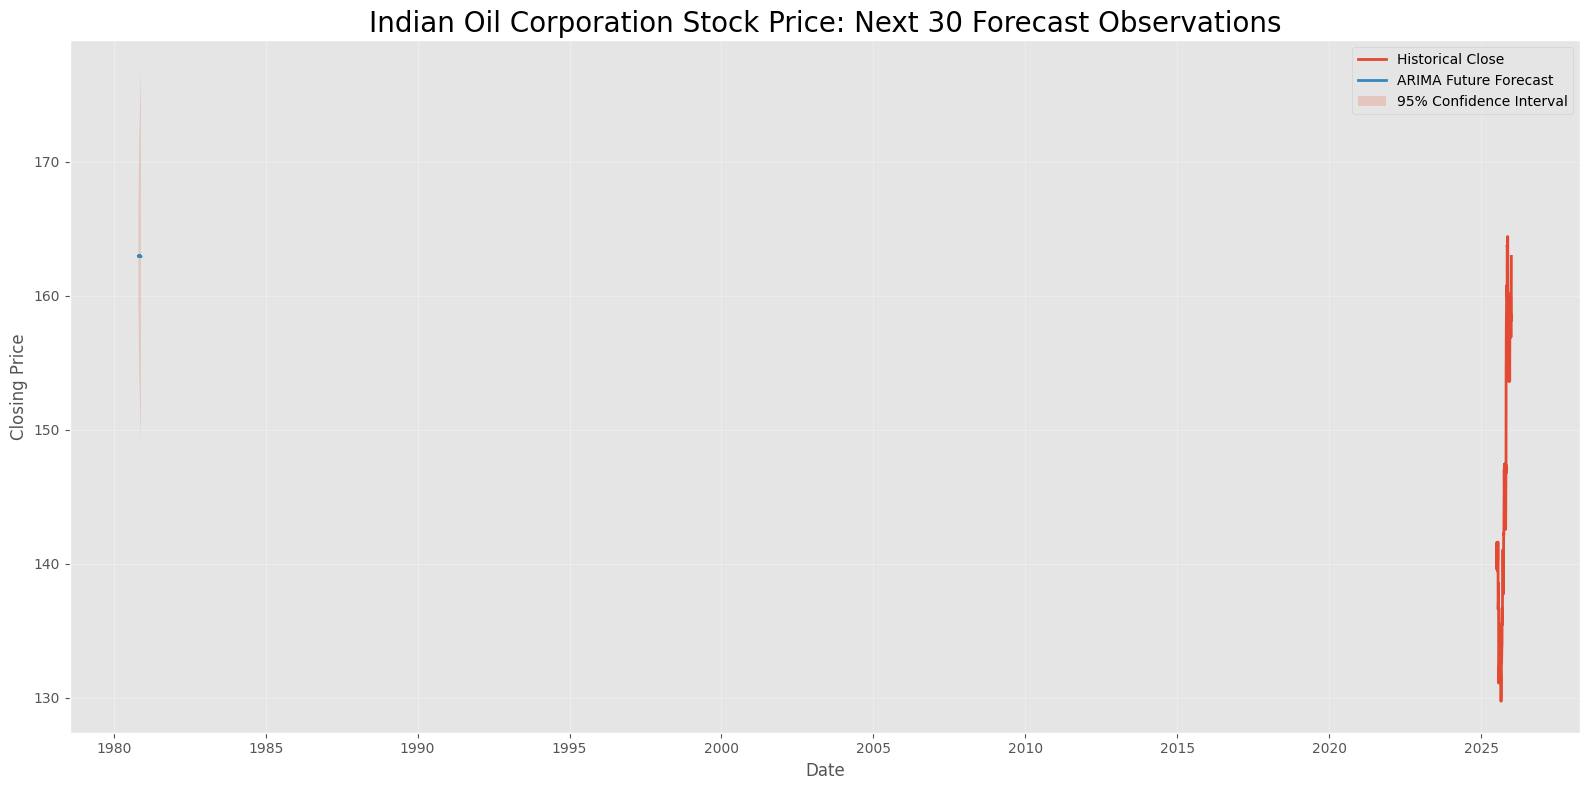

In [51]:

plt.figure(
    figsize=(16, 8)
)


recent_data = (
    IOC["Close"]
    .iloc[-120:]
)


plt.plot(
    recent_data.index,
    recent_data.values,
    label="Historical Close",
    linewidth=2
)


plt.plot(
    future_mean.index,
    future_mean.values,
    label=f"{selected_model} Future Forecast",
    linewidth=2
)


plt.fill_between(
    future_mean.index,
    future_ci.iloc[:, 0].values,
    future_ci.iloc[:, 1].values,
    alpha=0.2,
    label="95% Confidence Interval"
)


plt.title(
    f"Indian Oil Corporation Stock Price: "
    f"Next {future_steps} Forecast Observations",
    fontsize=20
)

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

The plot shows the recent IOC closing prices together with the
selected ARIMA(1,1,1) model’s future forecast. The shaded region
represents the 95% confidence interval, showing the uncertainty
around the predicted prices.

## Conclusion

In [52]:

print(
    "\n" + "=" * 70
)

print(
    "INDIAN OIL CORPORATION "
    "TIME SERIES ANALYSIS - FINAL SUMMARY"
)

print(
    "=" * 70
)


print(
    "\nBest ARIMA Order:"
)

print(
    best_arima_order
)


print(
    "\nARIMA Test Performance:"
)

print(
    f"MAE  : {final_arima_mae:.4f}"
)

print(
    f"RMSE : {final_arima_rmse:.4f}"
)


print(
    "\nBest SARIMA Order:"
)

print(
    best_sarima_order
)


print(
    "\nBest SARIMA Seasonal Order:"
)

print(
    best_sarima_seasonal_order
)


if sarima_success:

    print(
        "\nSARIMA Test Performance:"
    )

    print(
        f"MAE  : {final_sarima_mae:.4f}"
    )

    print(
        f"RMSE : {final_sarima_rmse:.4f}"
    )

else:

    print(
        "\nSARIMA failed during "
        "final test evaluation."
    )


print(
    "\nNaive Random Walk Test Performance:"
)

print(
    f"MAE  : {naive_test_mae:.4f}"
)

print(
    f"RMSE : {naive_test_rmse:.4f}"
)


print(
    "\nFinal Model Ranking:"
)

print(
    final_comparison
)


print(
    "\nSelected Model for Future Forecasting:"
)

print(
    selected_model
)


print(
    "\n" + "=" * 70
)

print(
    "Analysis completed successfully."
)

print(
    "=" * 70
)


INDIAN OIL CORPORATION TIME SERIES ANALYSIS - FINAL SUMMARY

Best ARIMA Order:
(1, 1, 1)

ARIMA Test Performance:
MAE  : 1.4752
RMSE : 2.0399

Best SARIMA Order:
(1, 1, 1)

Best SARIMA Seasonal Order:
(1, 0, 1, 5)

SARIMA Test Performance:
MAE  : 1.4763
RMSE : 2.0440

Naive Random Walk Test Performance:
MAE  : 1.4874
RMSE : 2.0474

Final Model Ranking:
                          Model       MAE      RMSE
0                ARIMA(1, 1, 1)  1.475173  2.039916
1  SARIMA(1, 1, 1)x(1, 0, 1, 5)  1.476306  2.043985
2             Naive Random Walk  1.487398  2.047364

Selected Model for Future Forecasting:
ARIMA

Analysis completed successfully.


The final summary brings together the selected ARIMA and SARIMA models, their test performance, and the naïve benchmark results. It also displays the final model ranking and identifies ARIMA(1,1,1) as the selected model for future forecasting.